In [27]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import binned_statistic
from src.loading import load_dyamond_feature_stats, load_imerg_feature_stats
from src.plotting import array_midpoints

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
data_packet = {
    'IMERG': load_imerg_feature_stats(),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', '0p1'),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', '0p1'),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', '0p1'),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', '0p1'),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', '0p1'),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', '0p1'),
}

Text(0.5, 0, 'PF Area [km2]')

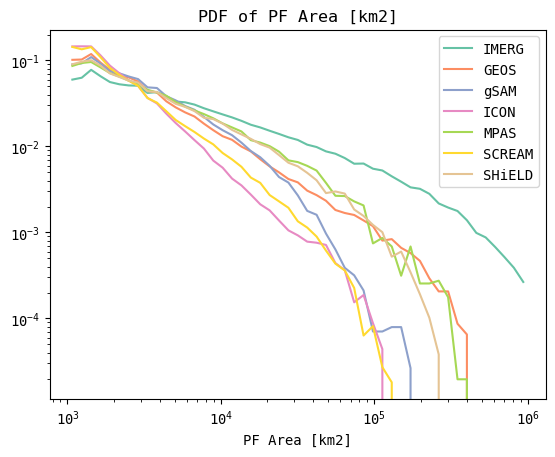

In [30]:
fig, ax = plt.subplots()
area_bins = np.logspace(3, 6, 50)
for model_name, model_data in data_packet.items():
    counts = binned_statistic(
        model_data['area_km2'],
        None, 
        statistic='count', 
        bins=area_bins
    ).statistic

    pdf = counts / counts.sum()

    ax.plot(
        array_midpoints(area_bins),
        pdf,
        label=model_name
    )

ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('PDF of PF Area [km2]')
ax.set_xlabel('PF Area [km2]')

In [39]:
model_data['max_precip_mm_hr'].max()

186.4773712158203

55.09749857584635
268.554931640625
220.60943603515625
246.8975067138672
195.62564086914062
194.01571655273438
186.4773712158203


Text(0.5, 0, 'PF Area [km2]')

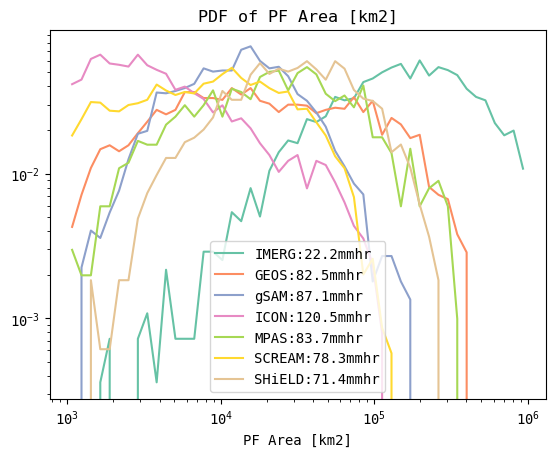

In [40]:
fig, ax = plt.subplots()
area_bins = np.logspace(3, 6, 50)
for model_name, model_data in data_packet.items():
    print(model_data['max_precip_mm_hr'].max())
    pr_thresh = model_data['max_precip_mm_hr'].quantile(0.99) 
    model_data = model_data.filter(
        pl.col("max_precip_mm_hr")>=pr_thresh
    )
    counts = binned_statistic(
        model_data['area_km2'],
        None, 
        statistic='count', 
        bins=area_bins
    ).statistic

    pdf = counts / counts.sum()

    ax.plot(
        array_midpoints(area_bins),
        pdf,
        label=f'{model_name}:{pr_thresh:0.1f}mmhr'
    )

ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('PDF of PF Area [km2]')
ax.set_xlabel('PF Area [km2]')